# Football Player Evaluation Model - Analysis



## 0. Setup - Imports and Configuration

In [62]:
import pandas as pd
import tensorflow as tf

import config
from src.analysis.game_utils import game_summary
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.models.attention_lstm import AttentionLayer
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.xthreat import get_default_xt_model

In [49]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [50]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
all_matches = list(data)

# Sort matches by game_date
all_matches.sort(key=lambda x: x[0].get('game_date', ''), reverse=True)

len(all_matches)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

51

### 1.1 Validation Set Matches Information

In [51]:
matches_info = []

for match, events_df in all_matches:
    summary = game_summary(match)
    matches_info.append(summary)

for match in matches_info:
    print(match)


Spain 2 : 1 England (Final) [14.07.2024]
Netherlands 1 : 2 England (Semi-finals) [10.07.2024]
Spain 2 : 1 France (Semi-finals) [09.07.2024]
Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024]
England 1 : 1 Switzerland (Quarter-finals) [06.07.2024]
Portugal 0 : 0 France (Quarter-finals) [05.07.2024]
Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]
Austria 1 : 2 Turkey (Round of 16) [02.07.2024]
Romania 0 : 3 Netherlands (Round of 16) [02.07.2024]
Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024]
France 1 : 0 Belgium (Round of 16) [01.07.2024]
Spain 4 : 1 Georgia (Round of 16) [30.06.2024]
England 2 : 1 Slovakia (Round of 16) [30.06.2024]
Germany 2 : 0 Denmark (Round of 16) [29.06.2024]
Switzerland 2 : 0 Italy (Round of 16) [29.06.2024]
Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024]
Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]
Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]
Denmark 0 : 0 Serbia (Group Stage) [25.06.2024

## 2. Load Trained Model

In [52]:
# Load the best trained model
model_path = f"models/{config.MODEL_TYPE}/best_model.keras"
model = tf.keras.models.load_model(model_path, custom_objects={'AttentionLayer': AttentionLayer})
print(f"Model loaded from: {model_path}")
print(f"Model type: {config.MODEL_TYPE}")


Model loaded from: models/attention_lstm/best_model.keras
Model type: attention_lstm


In [53]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 45)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       178,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,151,255 (4.39 MB)

 Trainable params: 383,751 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 767,504 (2.93 MB)

## 3. Preprocess Data for Analysis

In [54]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_matches(all_matches)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
→Processing match 3942819: 3485 events
 → Generated 82 sequences, 82 labels for match 3942819
→Processing match 3942752: 3328 events
 → Generated 107 sequences, 107 labels for match 3942752
→Processing match 3942382: 3415 events
 → Generated 91 sequences, 91 labels for match 3942382
→Processing match 3942227: 4882 events
 → Generated 105 sequences, 105 labels for match 3942227
→Processing match 3942349: 5190 events
 → Generated 131 sequences, 131 labels for match 3942349
→Processing match 3942226: 4463 events
 → Generated 138 sequences, 138 labels for match 3942226
→Processing match 3941022: 3722 events
 → Generated 104 sequences, 104 labels for match 3941022
→Processing match 3941021: 2996 events
 → Generated 98 sequences, 98 labels for match 3941021
→Processing match 3941020: 4221 events
 → Generated 124 sequences, 124 labels for match 3941020
→Processing match 3941019: 3941 events
 → Genera

## 4. Analysis


### 4.1 Single Match Analysis - Final Match

#### Load and analyze the final match

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from src.ml.preprocessing.possessions_extraction import extract_possessions, tail_dataframes_to_sequence_length
from src.analysis.visualization import plot_multiple_possessions, _title_with_value
selected_match, selected_events = all_matches[0]
selected_match_id = selected_match.get('match_id', selected_match.get('game_id', 'N/A'))

print(f"\nAnalyzing match: {game_summary(selected_match)}")
print(f"Events in match: {len(selected_events)}")



Analyzing match: Spain 2 : 1 England (Final) [14.07.2024]
Events in match: 3312


#### Preprocess match into sequences

In [56]:
preprocessor_analysis = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

X_match, y_match, p_match = preprocessor_analysis.process_match(selected_match_id, selected_match, selected_events)
print(f"Created {len(X_match)} sequences from {len(selected_events)} events")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
Created 86 sequences from 3312 events


#### Make predictions on match sequences

In [66]:
predictions = model.predict(X_match, batch_size=32, verbose=0)

predicted_values = predictions['value'].flatten()
attention_weights = predictions['attention_weights']  # Shape: (n_sequences, sequence_length)

print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")


Total sequences analyzed: 86
Sum of all predicted values: 2.606


#### Get top 8 sequences by predicted value

In [67]:
number_of_top_predictions = 8
top_indices = np.argsort(predicted_values)[-number_of_top_predictions:][::-1]

print(f"\nTop {number_of_top_predictions} sequences with highest predicted values:\n")
for i, idx in enumerate(top_indices):
    seq_value = predicted_values[idx]
    seq_weights = attention_weights[idx]
    possession_id = p_match[idx]
    max_weight_idx = np.argmax(seq_weights)

    print(f"{i + 1}. Sequence with possession id = {possession_id}: Value = {seq_value:.3f}")
    print(f"   Attention weights: {[f'{w:.3f}' for w in seq_weights]}")
    print(f"   Most important action: position {max_weight_idx} (weight: {seq_weights[max_weight_idx]:.3f})")
    print()



Top 8 sequences with highest predicted values:

1. Sequence with possession id = 136: Value = 0.248
   Attention weights: ['0.177', '0.184', '0.192', '0.181', '0.144', '0.123']
   Most important action: position 2 (weight: 0.192)

2. Sequence with possession id = 81: Value = 0.225
   Attention weights: ['0.167', '0.178', '0.190', '0.184', '0.150', '0.131']
   Most important action: position 2 (weight: 0.190)

3. Sequence with possession id = 117: Value = 0.181
   Attention weights: ['0.159', '0.170', '0.191', '0.191', '0.155', '0.133']
   Most important action: position 3 (weight: 0.191)

4. Sequence with possession id = 83: Value = 0.132
   Attention weights: ['0.177', '0.169', '0.185', '0.180', '0.150', '0.139']
   Most important action: position 2 (weight: 0.185)

5. Sequence with possession id = 69: Value = 0.105
   Attention weights: ['0.161', '0.165', '0.186', '0.188', '0.158', '0.142']
   Most important action: position 3 (weight: 0.188)

6. Sequence with possession id = 105: V

#### Visualize top 8 possessions on the pitch

Visualizing top 8 possessions...


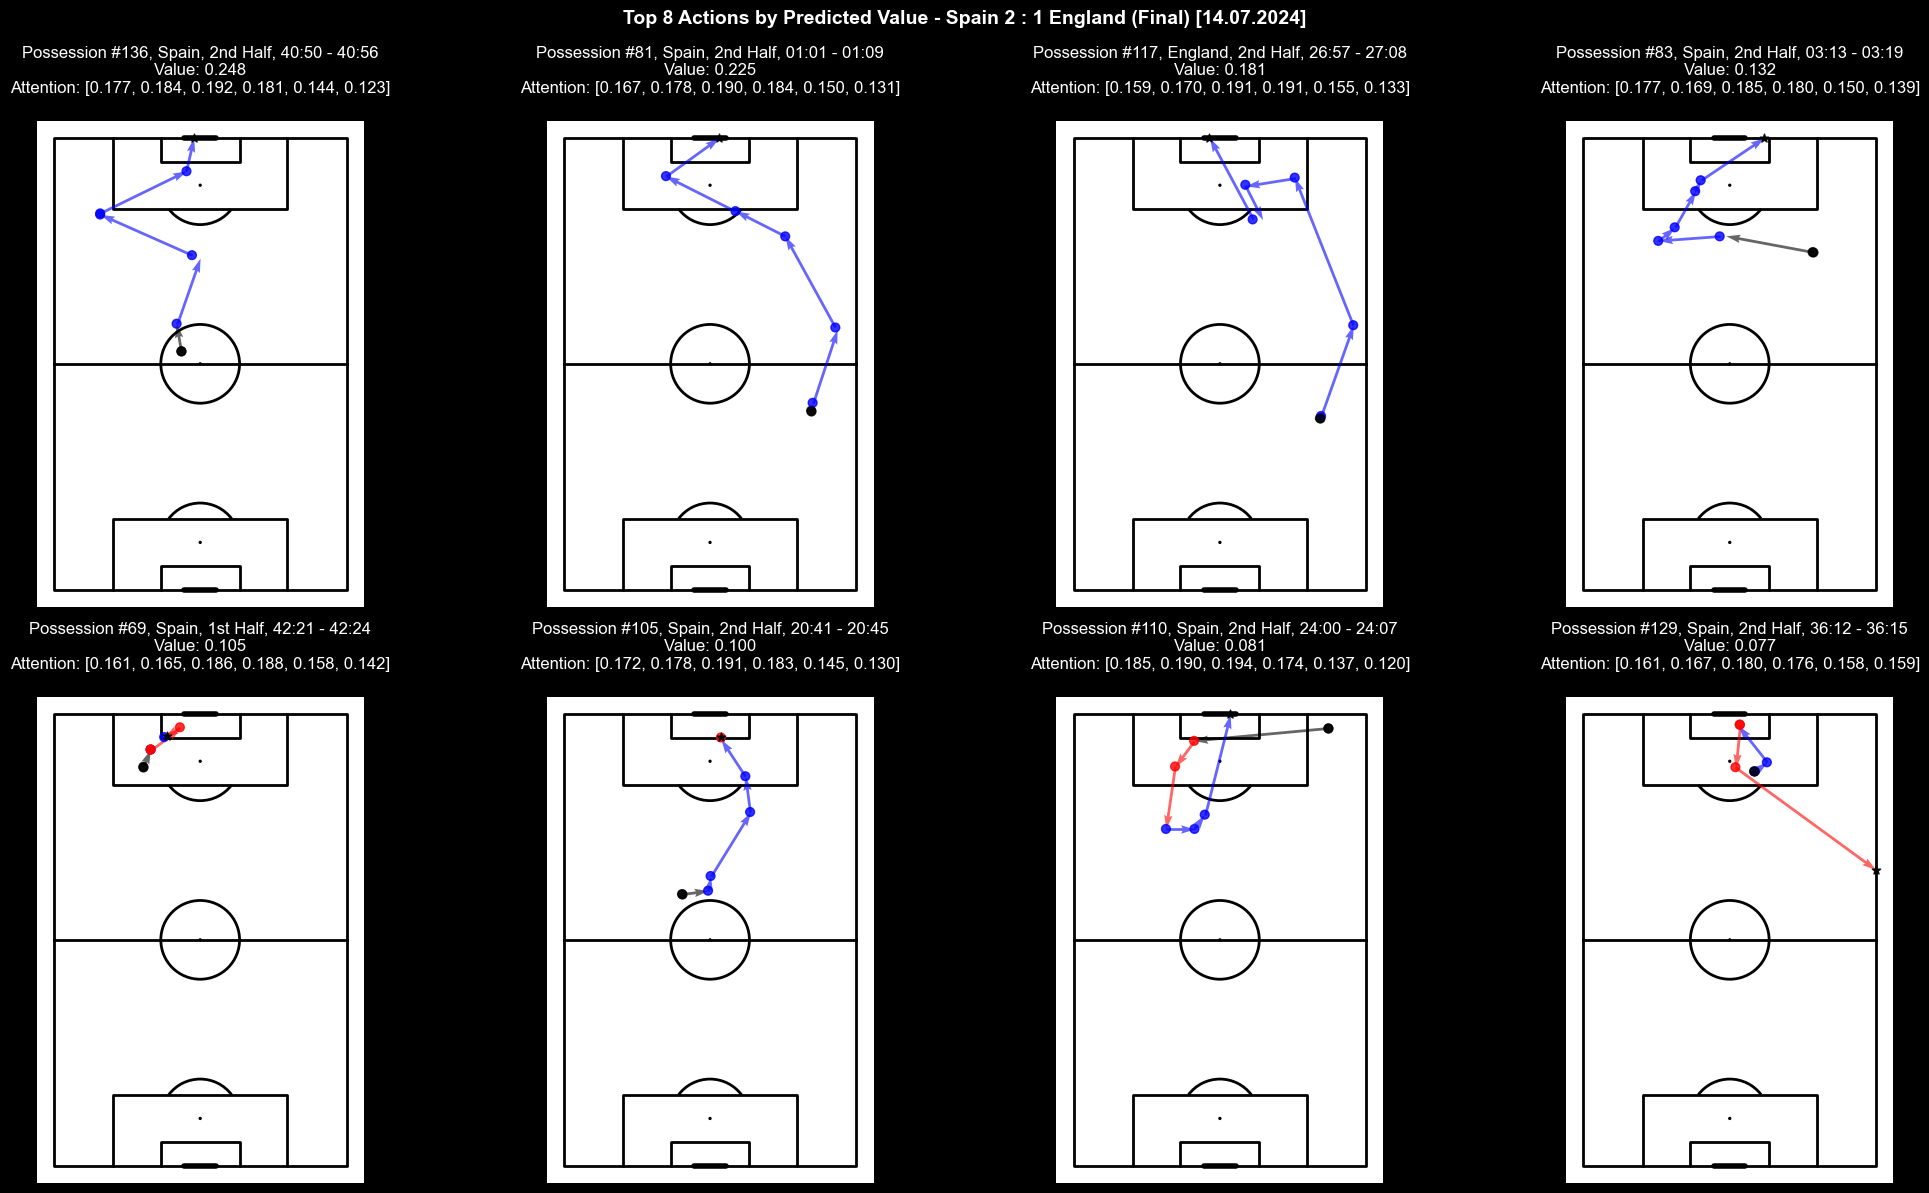

In [68]:
print("Visualizing top 8 possessions...")

top_possessions = [extract_possessions(selected_match, selected_events)[p_match[idx]] for idx in top_indices]
top_possessions = tail_dataframes_to_sequence_length(top_possessions, config.SEQUENCE_LENGTH)

top_possession_titles = []
for i, idx in enumerate(top_indices):
    possession = top_possessions[i]
    predicted_value = predicted_values[idx]
    attention_weight = attention_weights[idx]
    top_possession_titles.append(_title_with_value(possession, predicted_value, attention_weight))

fig = plot_multiple_possessions(top_possessions, titles=top_possession_titles,
                                main_title=f"Top {number_of_top_predictions} Actions by Predicted Value - {game_summary(selected_match)}")
plt.tight_layout()
plt.show()


## 6. Summary and Results

In [ ]:
# Save training metrics and plots
trainer.save_training_metrics(all_metrics)
trainer.plot_training_history(filename="training_history.png")

print("Pipeline completed successfully!")
print(f"Best model saved as: models/{config.MODEL_TYPE}/best_model.keras")

## 7. Analysis

In [23]:
# Extract match information from validation set
validation_matches_info = []

for match, events_df in val_matches:
    # try:
    summary = game_summary(match)
    # except KeyError:
    #     # Fallback if match structure is different
    #     summary = f"{match.get('home_team', 'N/A')} vs {match.get('away_team', 'N/A')}"

    match_info = {
        'match_id': match.get('match_id', match.get('game_id', 'N/A')),
        'summary': summary,
    }
    validation_matches_info.append(match_info)

# Create DataFrame with validation matches info
val_matches_df = pd.DataFrame(validation_matches_info)
print("Validation Set Matches:")
print(val_matches_df)

Validation Set Matches:
   match_id                                            summary
0   3930166  Portugal 2 : 1 Czech Republic (Group Stage) [1...
1   3930165    Austria 0 : 1 France (Group Stage) [17.06.2024]
2   3938645   Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
3   3938637  Poland 1 : 2 Netherlands (Group Stage) [16.06....
4   3941017  England 2 : 1 Slovakia (Round of 16) [30.06.2024]
5   3938642  Georgia 1 : 1 Czech Republic (Group Stage) [22...
6   3930177  Scotland 0 : 1 Hungary (Group Stage) [23.06.2024]
7   3941021  Romania 0 : 3 Netherlands (Round of 16) [02.07...
8   3942382  Netherlands 2 : 1 Turkey (Quarter-finals) [06....


In [ ]:
# Summary statistics
print(f"\nValidation Set Summary:")
print(f"Total matches: {len(val_matches_df)}")
print(f"Total events: {val_matches_df['events_count'].sum()}")
print(f"Average events per match: {val_matches_df['events_count'].mean():.2f}")
